# Submission 2 Machine Learning Terapan - Bagus Angkasawan Sumantri Putra

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

**Penjelasan:** Library berikut diimpor untuk keperluan analisis data dan pembuatan model:
- `pandas` untuk manipulasi data tabular.
- `numpy` untuk operasi numerik.
- `seaborn` dan `matplotlib` untuk visualisasi data.
- `tensorflow` untuk membangun dan melatih model rekomendasi berbasis machine learning.
- `scikit-learn` untuk ekstraksi fitur teks (TF-IDF), pemodelan berbasis jarak terdekat, dan pembagian dataset untuk pelatihan model.

## Membaca Data

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")


**Penjelasan:** Membaca tiga file CSV yang berisi data film, rating pengguna, dan tag yang diberikan pengguna untuk film:
- `movies.csv`: Berisi ID film, judul, dan genre.
- `ratings.csv`: Menyimpan data rating yang diberikan oleh pengguna terhadap film tertentu.
- `tags.csv`: Menyimpan tag yang diberikan pengguna pada film untuk mendeskripsikan preferensi atau aspek penting dari film tersebut.

## Informasi Data

In [3]:
print("Jumlah film:", movies.shape)
print("Jumlah rating:", ratings.shape)
print("Jumlah tag:", tags.shape)

print("\nContoh data movies:")
print(movies.head())

print("\nContoh data ratings:")
print(ratings.head())

print("\nContoh data tags:")
print(tags.head())


Jumlah film: (9742, 3)
Jumlah rating: (100836, 4)
Jumlah tag: (3683, 4)

Contoh data movies:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Contoh data ratings:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Contoh data tags:
   userId  movieId              tag   times

**Penjelasan:** Dataset memiliki:
- **9.742** film, mencerminkan variasi pilihan yang luas.
- **100.836** rating pengguna, memberikan data yang cukup untuk membangun model rekomendasi.
- **3.683** tag, yang dapat digunakan untuk mendukung pendekatan berbasis konten dalam sistem rekomendasi.

Ditampilkan juga contoh lima baris pertama dari setiap dataset untuk melihat struktur datanya.

In [4]:
print("Missing values pada data movies:")
print(movies.isnull().sum())

print("\nMissing values pada data ratings:")
print(ratings.isnull().sum())

print("\nMissing values pada data tags:")
print(tags.isnull().sum())

Missing values pada data movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values pada data ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values pada data tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


**Penjelasan:** Dilakukan pemeriksaan terhadap missing values di semua dataset dan hasilnya menunjukkan **tidak ada nilai yang hilang**. Ini berarti dataset telah bersih dan siap digunakan untuk analisis lebih lanjut tanpa perlu penanganan tambahan.

In [5]:
print("Jumlah data duplikat pada movies:", movies.duplicated().sum())
print("Jumlah data duplikat pada ratings:", ratings.duplicated().sum())
print("Jumlah data duplikat pada tags:", tags.duplicated().sum())

Jumlah data duplikat pada movies: 0
Jumlah data duplikat pada ratings: 0
Jumlah data duplikat pada tags: 0


**Penjelasan:** Diperiksa apakah terdapat data duplikat pada ketiga dataset dan hasilnya menunjukkan **tidak ada duplikasi data**. Ini memastikan data yang digunakan unik dan tidak menyebabkan bias dalam analisis.

In [6]:
Q1 = ratings['rating'].quantile(0.25)
Q3 = ratings['rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ratings[(ratings['rating'] < lower_bound) | (ratings['rating'] > upper_bound)]
num_outliers = len(outliers)

print(f"Jumlah outlier: {num_outliers}")


Jumlah outlier: 4181


**Penjelasan:** Dari analisis **Interquartile Range (IQR)**, ditemukan **4.181** rating sebagai outlier. Outlier ini tetap digunakan karena masih berada dalam rentang yang wajar dan mencerminkan preferensi unik pengguna.

## Visualisasi Data

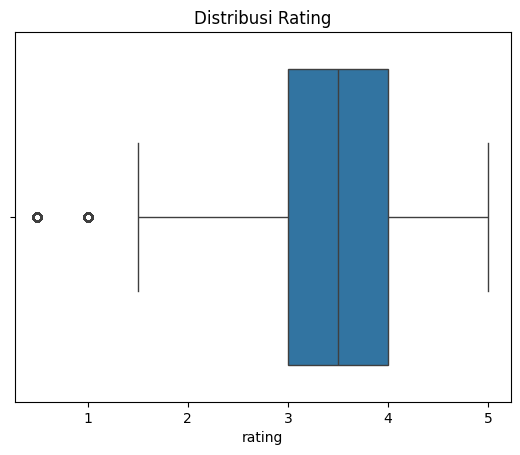

In [ ]:
sns.boxplot(x=ratings['rating'])
plt.title('Distribusi Rating')
plt.show()

**Penjelasan:** Box plot menunjukkan bahwa mayoritas rating berada di antara **3 dan 4**, menandakan bahwa pengguna cenderung memberikan rating positif untuk film yang mereka tonton.

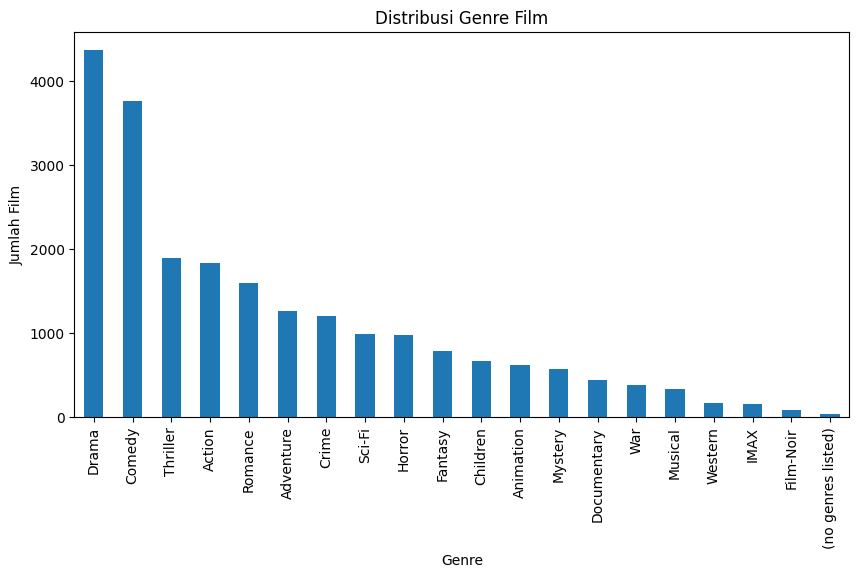

In [ ]:
genre_counts = movies['genres'].str.get_dummies(sep='|').sum()
genre_counts.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title('Distribusi Genre Film')
plt.xlabel('Genre')
plt.ylabel('Jumlah Film')
plt.show()

**Penjelasan:** Bar chart menunjukkan bahwa **Drama** adalah genre yang paling umum dalam dataset, diikuti oleh **Comedy**, yang menandakan bahwa film bergenre ini paling banyak tersedia dalam data dan kemungkinan besar memiliki minat tinggi dari pengguna.

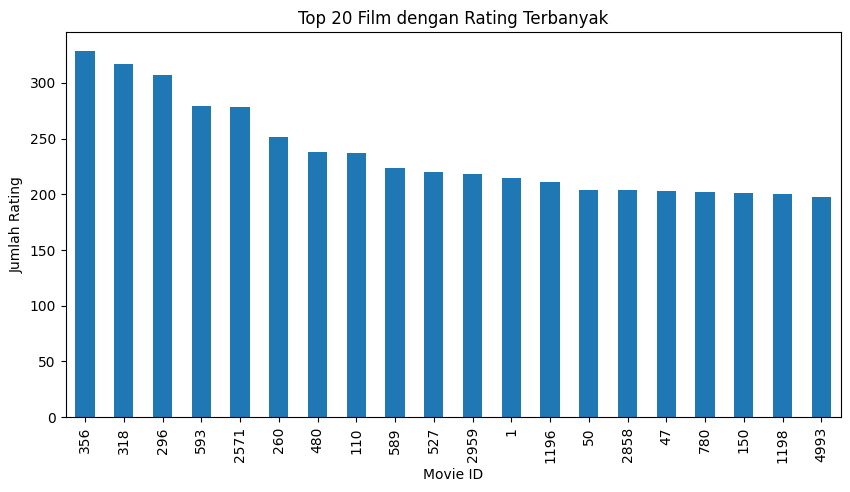

In [ ]:
rating_counts = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)
rating_counts.head(20).plot(kind='bar', figsize=(10,5))
plt.title('Top 20 Film dengan Rating Terbanyak')
plt.xlabel('Movie ID')
plt.ylabel('Jumlah Rating')
plt.show()

**Penjelasan:** Visualisasi bar chart menunjukkan 20 film dengan jumlah rating tertinggi. Ini membantu dalam memahami film mana yang paling banyak dinilai oleh pengguna, yang dapat berkontribusi pada sistem rekomendasi berbasis popularitas.

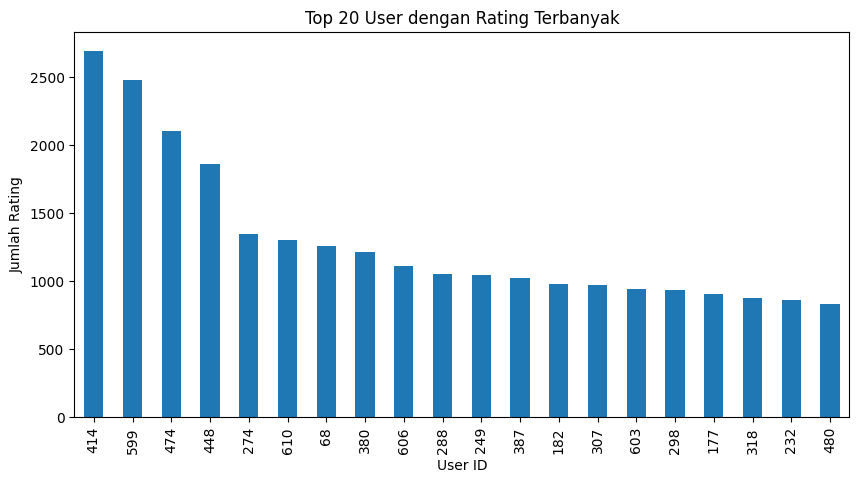

In [ ]:
user_ratings = ratings.groupby('userId')['rating'].count().sort_values(ascending=False)
user_ratings.head(20).plot(kind='bar', figsize=(10,5))
plt.title('Top 20 User dengan Rating Terbanyak')
plt.xlabel('User ID')
plt.ylabel('Jumlah Rating')
plt.show()

**Penjelasan:** Menampilkan daftar 20 pengguna yang memberikan rating terbanyak. Pengguna aktif ini mungkin memiliki preferensi yang lebih spesifik, sehingga dapat memberikan wawasan terhadap perilaku penonton dalam sistem rekomendasi.


## Preprocessing Data (Content-Based Filtering)

In [ ]:
tags_agg = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
movies_with_tags = pd.merge(movies, tags_agg, on='movieId', how='left')

movies_with_tags['combined'] = movies_with_tags['genres'].fillna('') + ' ' + movies_with_tags['tag'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies_with_tags['combined'])

title_to_index = pd.Series(movies_with_tags.index, index=movies_with_tags['title']).drop_duplicates()


**Penjelasan:**
- Tag di setiap film digabungkan agar setiap `movieId` memiliki satu string teks yang berisi semua tag.
- Data film kemudian digabungkan dengan hasil agregasi tag untuk memperkaya informasi.
- Kolom `combined` dibuat untuk menggabungkan genre dan tag dalam satu representasi teks.
- Data teks ini diproses menggunakan **TF-IDF**, yang membantu merepresentasikan relevansi kata-kata dalam fitur numerik berbasis frekuensi.
- Mapping `title_to_index` dibuat agar sistem rekomendasi dapat dengan mudah mengakses indeks berdasarkan judul film.

## Modeling & Rekomendasi (Content-Based Filtering)

In [ ]:
nn_model = NearestNeighbors(metric='cosine', algorithm='brute')
nn_model.fit(tfidf_matrix)

def recommend_content(title, top_n=5):
    idx = title_to_index[title]
    distances, indices = nn_model.kneighbors(tfidf_matrix[idx], n_neighbors=top_n + 1)
    indices = indices.flatten()[1:]
    return movies_with_tags.iloc[indices][['title', 'genres']]

print("Rekomendasi mirip Pinocchio:")
print(recommend_content("Pinocchio (1940)"))

Rekomendasi mirip Pinocchio:
                                      title  \
981                         Fantasia (1940)   
511  Snow White and the Seven Dwarfs (1937)   
780                       Cinderella (1950)   
789              Alice in Wonderland (1951)   
786                            Dumbo (1941)   

                                           genres  
981            Animation|Children|Fantasy|Musical  
511      Animation|Children|Drama|Fantasy|Musical  
780    Animation|Children|Fantasy|Musical|Romance  
789  Adventure|Animation|Children|Fantasy|Musical  
786              Animation|Children|Drama|Musical  


**Penjelasan:**
- **Model Nearest Neighbors** dibuat menggunakan **cosine similarity**, yang cocok untuk teks karena menilai kemiripan berdasarkan pola distribusi kata.
- Model dilatih menggunakan **TF-IDF matrix**, sehingga setiap film direpresentasikan oleh fitur numerik yang mencerminkan genre dan tag.
- Fungsi `recommend_movies()`:
  - Mengambil indeks film berdasarkan judul.
  - Mencari film yang paling mirip menggunakan **knn.kneighbors**.
  - Mengambil `n_neighbors` terdekat, kecuali film yang diminta (karena film itu tidak perlu direkomendasikan ke dirinya sendiri).
  - Mengembalikan film yang paling relevan berdasarkan kemiripan teks.

## Preprocessing Data (Collaborative Filtering)

In [ ]:
df = ratings.copy()

user_ids = df['userId'].unique().tolist()
movie_ids = df['movieId'].unique().tolist()

user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
movie_to_movie_encoded = {x: i for i, x in enumerate(movie_ids)}

user_encoded_to_user = {i: x for x, i in user_to_user_encoded.items()}
movie_encoded_to_movie = {i: x for x, i in movie_to_movie_encoded.items()}

df['user'] = df['userId'].map(user_to_user_encoded)
df['movie'] = df['movieId'].map(movie_to_movie_encoded)

min_rating = df['rating'].min()
max_rating = df['rating'].max()

df['rating_normalized'] = df['rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating))


**Penjelasan:** Melakukan preprocessing data rating dengan meng-encode ID pengguna dan ID film, serta menormalisasi nilai rating.

## Pembagian Data Latih dan Validasi (Collaborative Filtering)

In [ ]:
x = df[['user', 'movie']].values
y = df['rating_normalized'].values

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)


**Penjelasan:** Membagi data rating menjadi data latih dan data validasi dengan rasio 80:20 dan menggunakan random_state untuk memastikan pembagian data yang konsisten.

## Model Rekomendasi Deep Learning (Collaborative Filtering)

In [ ]:
class RecommenderNet(tf.keras.Model):
    def __init__(self, num_users, num_movies, embedding_size=50, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.user_embedding = layers.Embedding(num_users, embedding_size, embeddings_initializer='he_normal', embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.user_bias = layers.Embedding(num_users, 1)
        self.movie_embedding = layers.Embedding(num_movies, embedding_size, embeddings_initializer='he_normal', embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.movie_bias = layers.Embedding(num_movies, 1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        movie_vector = self.movie_embedding(inputs[:, 1])
        movie_bias = self.movie_bias(inputs[:, 1])
        dot_user_movie = tf.tensordot(user_vector, movie_vector, 2)
        x = dot_user_movie + user_bias + movie_bias
        return tf.nn.sigmoid(x)


**Penjelasan:** Model rekomendasi berbasis *deep learning* dibuat menggunakan **embedding** untuk merepresentasikan interaksi antara pengguna dan film:
- **Embedding layer** digunakan untuk menyimpan representasi numerik pengguna dan film.
- **Dot product** digunakan untuk menghitung keterkaitan antara pengguna dan film berdasarkan preferensi mereka.
- **Aktivasi sigmoid** diterapkan untuk mendapatkan nilai prediksi rating.

## Pelatihan Model (Collaborative Filtering)

In [ ]:
num_users = len(user_to_user_encoded)
num_movies = len(movie_to_movie_encoded)

model = RecommenderNet(num_users, num_movies, embedding_size=50)
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=[tf.keras.metrics.RootMeanSquaredError()])

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_val, y_val)
)


Epoch 1/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.6602 - root_mean_squared_error: 0.2557 - val_loss: 0.6194 - val_root_mean_squared_error: 0.2152
Epoch 2/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.6163 - root_mean_squared_error: 0.2112 - val_loss: 0.6184 - val_root_mean_squared_error: 0.2137
Epoch 3/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.6092 - root_mean_squared_error: 0.2048 - val_loss: 0.6137 - val_root_mean_squared_error: 0.2090
Epoch 4/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.6075 - root_mean_squared_error: 0.2018 - val_loss: 0.6124 - val_root_mean_squared_error: 0.2077
Epoch 5/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.6073 - root_mean_squared_error: 0.2029 - val_loss: 0.6125 - val_root_mean_squared_error: 0.2078
Epoch 6/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.6068 - root_mean_squared_error: 0.2010 - val_loss: 0.6098 - val_root_mean_squared_error: 0.2046
Epoch 7/10
1261/1261 ━━━━━━━━━━━━

**Penjelasan:** Model dilatih menggunakan **10 epoch** dengan batch size **64**. Selama pelatihan, **Root Mean Squared Error (RMSE)** menunjukkan penurunan yang konsisten, mengindikasikan bahwa model semakin memahami pola rating pengguna.

In [ ]:
train_rmse_last = history.history['root_mean_squared_error'][-1]
val_rmse_last = history.history['val_root_mean_squared_error'][-1]
print(f"Final RMSE - Train: {train_rmse_last:.4f}, Validation: {val_rmse_last:.4f}")

Final RMSE - Train: 0.1966, Validation: 0.2030


**Penjelasan:** RMSE **pada data latih** adalah **0.196** dan **pada data validasi** adalah **0.203**, yang menunjukkan bahwa model memiliki performa yang cukup baik dan tidak mengalami overfitting.

## Evaluasi Model (Collaborative Filtering)

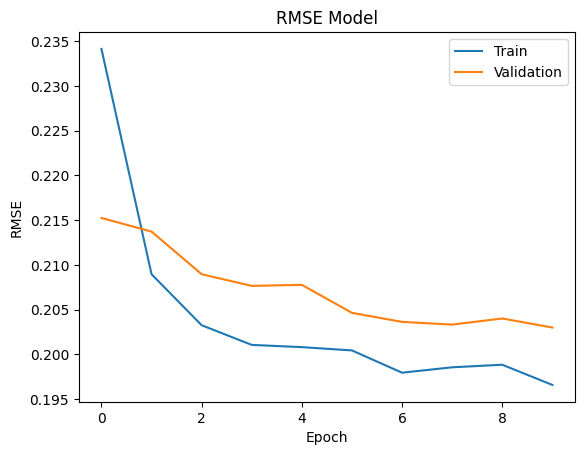

In [ ]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('RMSE Model')
plt.ylabel('RMSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


**Penjelasan:** Grafik RMSE ditampilkan untuk melihat perkembangan performa model selama pelatihan. Model menunjukkan hasil yang stabil setelah beberapa epoch, menandakan bahwa proses pelatihan berjalan optimal.

## Rekomendasi Film (Collaborative Filtering)

In [ ]:
user_id = 356
top_n = 10

encoded_user_id = user_to_user_encoded[user_id]

rated_movie_ids = df[df['userId'] == user_id]['movieId'].values
encoded_rated_movie_ids = [movie_to_movie_encoded[movie_id] for movie_id in rated_movie_ids]

all_movie_ids = set(range(num_movies))

not_rated_movie_ids = list(all_movie_ids - set(encoded_rated_movie_ids))

user_movie_array = np.hstack((
    np.full((len(not_rated_movie_ids), 1), encoded_user_id),
    np.array(not_rated_movie_ids).reshape(-1, 1)
))

predicted_ratings = model.predict(user_movie_array).flatten()

top_indices = predicted_ratings.argsort()[-top_n:][::-1]
top_movie_encoded_ids = [not_rated_movie_ids[i] for i in top_indices]
top_movie_ids = [movie_encoded_to_movie[i] for i in top_movie_encoded_ids]

print(f"Showing recommendations for user: {user_id}")
print("=" * 40)

print("Film dengan rating tertinggi dari user")
print("-" * 40)
top_rated_user_movies = (
    df[df['userId'] == user_id]
    .sort_values(by='rating', ascending=False)
    .head(5)['movieId']
    .values
)

top_rated_movies_info = movies[movies['movieId'].isin(top_rated_user_movies)]
for row in top_rated_movies_info.itertuples():
    print(f"{row.title} - Genre: {row.genres}")

print("-" * 40)
print(f"Top {top_n} film rekomendasi")
print("-" * 40)

recommended_movies = movies[movies['movieId'].isin(top_movie_ids)]
for row in recommended_movies.itertuples():
    print(f"{row.title} - Genre: {row.genres}")


295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Showing recommendations for user: 356
Film dengan rating tertinggi dari user
----------------------------------------
Grand Day Out with Wallace and Gromit, A (1989) - Genre: Adventure|Animation|Children|Comedy|Sci-Fi
Dead Poets Society (1989) - Genre: Drama
Graduate, The (1967) - Genre: Comedy|Drama|Romance
Double Indemnity (1944) - Genre: Crime|Drama|Film-Noir
Roger Dodger (2002) - Genre: Comedy|Drama
----------------------------------------
Top 10 film rekomendasi
----------------------------------------
Pulp Fiction (1994) - Genre: Comedy|Crime|Drama|Thriller
Godfather, The (1972) - Genre: Crime|Drama
Philadelphia Story, The (1940) - Genre: Comedy|Drama|Romance
Rear Window (1954) - Genre: Mystery|Thriller
Star Wars: Episode V - The Empire Strikes Back (1980) - Genre: Action|Adventure|Sci-Fi
Brazil (1985) - Genre: Fantasy|Sci-Fi
Goodfellas (1990) - Genre: Crime|Drama
Amadeus (1984) - Genre: Drama
American History X (1998) - Genre: Crime|Drama

**Penjelasan:**
Berdasarkan prediksi model, ditampilkan:

1. 5 Film dengan rating tertinggi yang telah diberikan oleh pengguna.

2. 10 Film rekomendasi berdasarkan preferensi pengguna dalam sistem rekomendasi berbasis deep learning.

Struktur rekomendasi ini membantu memberikan rekomendasi yang lebih personal dan relevan bagi pengguna.